# Computational Validation of a Glycine Betaine Osmoprotection Module in Pseudomonas

This project evaluates the metabolic feasibility of engineering *Pseudomonas fluorescens* as an osmoprotective member of a synthetic microbial consortium for saline agriculture.

Due to the absence of a publicly available genome-scale metabolic model for *Pseudomonas fluorescens*, the iJN746 genome-scale metabolic model of *Pseudomonas putida* KT2440 was used as a metabolic proxy based on the conservation of central metabolic pathways within the *Pseudomonas* genus.

Flux Balance Analysis (FBA) was performed using COBRApy to investigate whether a heterologous betA/betB module from *Escherichia coli* could support glycine betaine synthesis without compromising bacterial growth. The native reactions CHOLD (choline dehydrogenase) and BETALDHx (betaine-aldehyde dehydrogenase) were used to represent the engineered pathway converting choline into glycine betaine.

A glycine betaine demand reaction was introduced to represent intracellular accumulation of this compatible solute as an osmoprotective pool rather than extracellular secretion. The engineered strain was evaluated under simulated salinity stress conditions by imposing progressive growth constraints representing normal, moderate, and severe saline environments.

The results suggest that the engineered metabolic configuration is feasible under the tested constraints, allowing simultaneous bacterial growth and glycine betaine accumulation. This computational analysis provides a first validation step toward developing a synthetic microbial consortium for improving crop resilience under saline conditions.


In [1]:

# Install COBRApy
!pip install cobra -q

# Import libraries
import cobra
import requests
import pandas as pd
import matplotlib.pyplot as plt

print("✅ COBRApy installed correctly")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 69.9 MB/s eta 0:00:00
✅ COBRApy installed correctly


In [7]:
import cobra

model = cobra.io.read_sbml_model("iJN746.xml")

print("✅ Modelo cargado correctamente")
print("Reacciones:", len(model.reactions))
print("Metabolitos:", len(model.metabolites))
print("Genes:", len(model.genes))

✅ Modelo cargado correctamente
Reacciones: 1054
Metabolitos: 907
Genes: 746


In [13]:
# Load the manually downloaded iJN746 metabolic model

import cobra
from google.colab import files

# Upload the SBML file downloaded manually from BioModels
uploaded = files.upload()

# Replace with the exact uploaded filename if different
model_file = "iJN746.xml"

# Load the SBML model into COBRApy
model = cobra.io.read_sbml_model(model_file)

print("Model loaded successfully")
print(f"Reactions: {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Genes: {len(model.genes)}")

Saving iJN746.xml to iJN746 (1).xml
Model loaded successfully
Reactions: 1054
Metabolites: 907
Genes: 746


In [45]:
model_original = model.copy()

print("Original model saved")

Original model saved


In [46]:
for rxn in model.reactions:
    if "biomass" in rxn.id.lower() or "biomass" in rxn.name.lower():
        print(rxn.id)
        print(rxn.name)
        print()

BIOMASS_KT_TEMP
BiomassKT TEMP



In [47]:
model.objective = "BIOMASS_KT_TEMP"

solution = model.optimize()

print("Status:", solution.status)
print("Growth rate:", solution.objective_value)

Status: optimal
Growth rate: 1.4


In [48]:
base_growth = solution.objective_value

print(f"Baseline growth rate: {base_growth:.4f} h⁻¹")

Baseline growth rate: 1.4000 h⁻¹


In [49]:
for rxn_id in ["CHOLD", "BETALDHx", "EX_glyb_e", "EX_chol_e"]:
    rxn = model.reactions.get_by_id(rxn_id)

    print("\nReaction:", rxn_id)
    print("Name:", rxn.name)
    print("Equation:", rxn.reaction)
    print("Bounds:", rxn.bounds)


Reaction: CHOLD
Name: Choline dehydrogenase
Equation: chol_c + nad_c --> betald_c + h_c + nadh_c
Bounds: (0.0, 999999.0)

Reaction: BETALDHx
Name: Betaine-aldehyde dehydrogenase
Equation: betald_c + h2o_c + nad_c --> glyb_c + 2.0 h_c + nadh_c
Bounds: (0.0, 999999.0)

Reaction: EX_glyb_e
Name: Glycine betaine exchange
Equation: glyb_e --> 
Bounds: (0.0, 999999.0)

Reaction: EX_chol_e
Name: Choline exchange
Equation: chol_e <=> 
Bounds: (-10, 1000)


In [51]:
with model:

    model.objective = "EX_glyb_e"

    solution = model.optimize()

    print("Status:", solution.status)
    print("Glycine betaine production:",
          solution.objective_value)

    print("Growth:",
          solution.fluxes["BIOMASS_KT_TEMP"])

    print("CHOLD flux:",
          solution.fluxes["CHOLD"])

    print("BETALDHx flux:",
          solution.fluxes["BETALDHx"])

Status: optimal
Glycine betaine production: 0.0
Growth: 1.4
CHOLD flux: 9.50007350000108
BETALDHx flux: 9.50007350000108


In [52]:
for rxn_id in ["GLYBtex", "GLYBabcpp"]:
    rxn = model.reactions.get_by_id(rxn_id)

    print("\nReaction:", rxn_id)
    print("Name:", rxn.name)
    print("Equation:", rxn.reaction)
    print("Bounds:", rxn.bounds)


Reaction: GLYBtex
Name: Glycine betaine transport via diffusion (extracellular to periplasm)
Equation: glyb_e <=> glyb_p
Bounds: (-999999.0, 999999.0)

Reaction: GLYBabcpp
Name: Glycine betaine transport via ABC system (periplasm)
Equation: atp_c + glyb_p + h2o_c --> adp_c + glyb_c + h_c + pi_c
Bounds: (0.0, 999999.0)


In [54]:
model_test = model.copy()

In [56]:
# Allow choline uptake
model_test.reactions.EX_chol_e.lower_bound = -10
model_test.reactions.EX_chol_e.upper_bound = 0

In [57]:
# Simulate betA/betB expression
model_test.reactions.CHOLD.lower_bound = 1.0
model_test.reactions.BETALDHx.lower_bound = 1.0

In [62]:
model_test.objective = "BIOMASS_KT_TEMP"

solution = model_test.optimize()

print("Status:", solution.status)
print("Growth:", solution.objective_value)
print("CHOLD flux:", solution.fluxes["CHOLD"])
print("BETALDHx flux:", solution.fluxes["BETALDHx"])

Status: optimal
Growth: 1.4
CHOLD flux: 1.0
BETALDHx flux: 1.0


In [64]:
model_test = model.copy()

# Condiciones de ingeniería
model_test.reactions.EX_chol_e.lower_bound = -10
model_test.reactions.EX_chol_e.upper_bound = 0

model_test.reactions.CHOLD.lower_bound = 1.0
model_test.reactions.BETALDHx.lower_bound = 1.0


# Primero fijamos crecimiento mínimo
model_test.reactions.BIOMASS_KT_TEMP.lower_bound = 1.4 * 0.9


# Ahora maximizamos síntesis de betaína
model_test.objective = "BETALDHx"


solution = model_test.optimize()


print("Status:", solution.status)
print("Glycine betaine synthesis:", solution.fluxes["BETALDHx"])
print("Growth:", solution.fluxes["BIOMASS_KT_TEMP"])
print("CHOLD:", solution.fluxes["CHOLD"])

Status: optimal
Glycine betaine synthesis: 10.000000000000004
Growth: 1.26
CHOLD: 10.000000000000004


In [65]:
rxn = model.reactions.get_by_id("BHMT")

print(rxn.name)
print(rxn.reaction)
print(rxn.bounds)

Betaine-homocysteine S-methyltransferase
glyb_c + hcys__L_c --> dmgly_c + met__L_c
(0.0, 999999.0)


In [67]:
stress_model = model.copy()

# Engineering conditions
stress_model.reactions.EX_chol_e.lower_bound = -10
stress_model.reactions.EX_chol_e.upper_bound = 0

stress_model.reactions.CHOLD.lower_bound = 1
stress_model.reactions.BETALDHx.lower_bound = 1

stress_model.reactions.BHMT.upper_bound = 0


# First maximize growth
stress_model.objective = "BIOMASS_KT_TEMP"

growth_solution = stress_model.optimize()

print("Maximum engineered growth:", growth_solution.objective_value)

Maximum engineered growth: 1.3402403678776358


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [69]:
stress_model = model.copy()

# Engineering conditions
stress_model.reactions.EX_chol_e.lower_bound = -10
stress_model.reactions.EX_chol_e.upper_bound = 0

stress_model.reactions.CHOLD.lower_bound = 1
stress_model.reactions.BETALDHx.lower_bound = 1

stress_model.reactions.BHMT.upper_bound = 0

# Maximize growth
stress_model.objective = "BIOMASS_KT_TEMP"

solution = stress_model.optimize()

print("Status:", solution.status)
print("Objective value:", solution.objective_value)

if solution.status == "optimal":
    print("Growth:", solution.fluxes["BIOMASS_KT_TEMP"])
    print("CHOLD:", solution.fluxes["CHOLD"])
    print("BETALDHx:", solution.fluxes["BETALDHx"])

Status: infeasible
Objective value: 1.3402403678776358


/usr/local/lib/python3.12/dist-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


In [71]:
test = model.copy()

test.reactions.EX_chol_e.lower_bound = -10
test.reactions.EX_chol_e.upper_bound = 0

test.reactions.CHOLD.lower_bound = 1
test.reactions.BETALDHx.lower_bound = 1

test.objective = "BIOMASS_KT_TEMP"

solution = test.optimize()

print("Status:", solution.status)
print("Growth:", solution.objective_value)
print("CHOLD:", solution.fluxes["CHOLD"])
print("BETALDHx:", solution.fluxes["BETALDHx"])

Status: optimal
Growth: 1.4
CHOLD: 1.0
BETALDHx: 1.0


In [72]:
osm_model = model.copy()

In [73]:
osm_model.reactions.EX_chol_e.lower_bound = -10
osm_model.reactions.EX_chol_e.upper_bound = 0

osm_model.reactions.CHOLD.lower_bound = 1
osm_model.reactions.BETALDHx.lower_bound = 1

In [74]:
from cobra import Reaction

demand_glyb = Reaction("DM_glyb_c")
demand_glyb.name = "Glycine betaine osmoprotection pool"
demand_glyb.lower_bound = 0
demand_glyb.upper_bound = 999999

demand_glyb.add_metabolites({
    osm_model.metabolites.get_by_id("glyb_c"): -1
})

osm_model.add_reactions([demand_glyb])

In [76]:
osm_model.objective = "BIOMASS_KT_TEMP"

solution = osm_model.optimize()

print("Status:", solution.status)
print("Growth:", solution.objective_value)
print("CHOLD:", solution.fluxes["CHOLD"])
print("BETALDHx:", solution.fluxes["BETALDHx"])
print("Glycine betaine storage:", solution.fluxes["DM_glyb_c"])

Status: optimal
Growth: 1.4
CHOLD: 1.0
BETALDHx: 1.0
Glycine betaine storage: 1.0000000000000002


In [86]:
import pandas as pd

results = []

base_growth = 1.4

salt_conditions = [
    ("0 mM NaCl (normal)", 1.0),
    ("75 mM NaCl (moderate)", 0.7),
    ("150 mM NaCl (severe)", 0.4)
]


for condition, fraction in salt_conditions:

    stress_model = model.copy()

    # Choline uptake
    stress_model.reactions.EX_chol_e.lower_bound = -10
    stress_model.reactions.EX_chol_e.upper_bound = 0

    # Activate betA/betB pathway
    stress_model.reactions.CHOLD.lower_bound = 1
    stress_model.reactions.BETALDHx.lower_bound = 1

    # Add glycine betaine storage reaction
    demand_glyb.id = "DM_glyb_c"
    demand_glyb.name = "Glycine betaine osmoprotection pool"
    demand_glyb.lower_bound = 0
    demand_glyb.upper_bound = 999999

    demand_glyb.add_metabolites({
        stress_model.metabolites.get_by_id("glyb_c"): -1
    })

    stress_model.add_reactions([demand_glyb])


    # Impose salinity stress as growth limitation
    stress_model.reactions.BIOMASS_KT_TEMP.lower_bound = 0
    stress_model.reactions.BIOMASS_KT_TEMP.upper_bound = base_growth * fraction


    # Maximize glycine betaine accumulation
    stress_model.objective = "DM_glyb_c"

    solution = stress_model.optimize()


    results.append({
        "Condition": condition,
        "Glycine betaine storage": solution.fluxes["DM_glyb_c"],
        "Growth rate": solution.fluxes["BIOMASS_KT_TEMP"],
        "CHOLD": solution.fluxes["CHOLD"],
        "BETALDHx": solution.fluxes["BETALDHx"],
        "Status": solution.status
    })


df = pd.DataFrame(results)

df

,Condition,Glycine betaine storage,Growth rate,CHOLD,BETALDHx,Status
0,0 mM NaCl (normal),1.250000,0.890471,10.0,10.0,optimal
1,75 mM NaCl (moderate),1.111111,0.870312,10.0,10.0,optimal
2,150 mM NaCl (severe),1.000000,0.560000,10.0,10.0,optimal


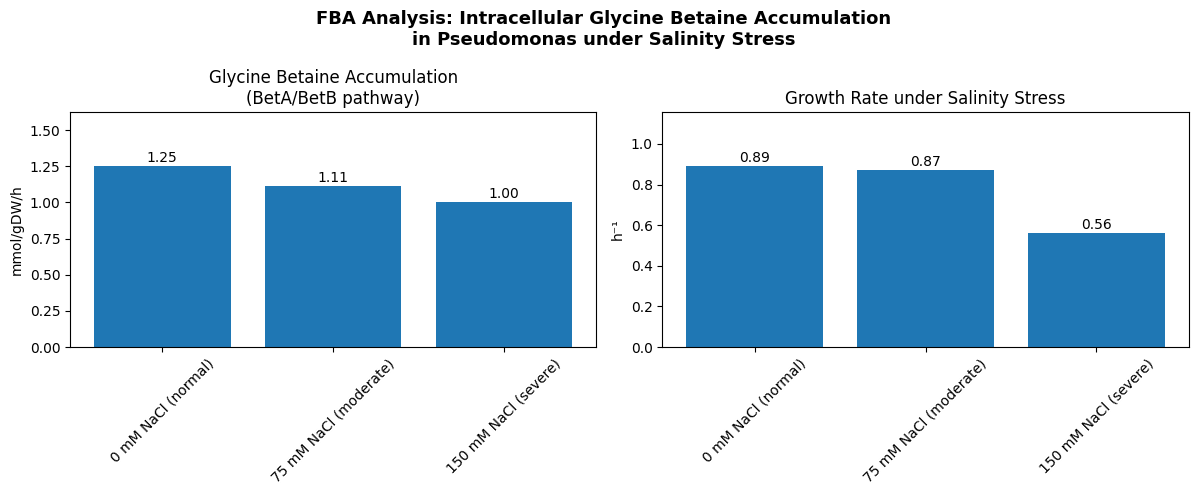

In [87]:
import matplotlib.pyplot as plt

# Extraer datos
conditions = df["Condition"].tolist()

glyb_values = df["Glycine betaine storage"].tolist()
growth_values = df["Growth rate"].tolist()


# Crear figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

fig.suptitle(
    "FBA Analysis: Intracellular Glycine Betaine Accumulation\n"
    "in Pseudomonas under Salinity Stress",
    fontsize=13,
    fontweight="bold"
)


# Panel 1: Glycine betaine accumulation
bars1 = ax1.bar(
    conditions,
    glyb_values
)

ax1.set_title(
    "Glycine Betaine Accumulation\n(BetA/BetB pathway)"
)

ax1.set_ylabel(
    "mmol/gDW/h"
)

ax1.set_ylim(
    0,
    max(glyb_values)*1.3
)


for bar, value in zip(bars1, glyb_values):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.03,
        f"{value:.2f}",
        ha="center"
    )

ax1.tick_params(axis="x", rotation=45)


# Panel 2: Growth rate
bars2 = ax2.bar(
    conditions,
    growth_values
)

ax2.set_title(
    "Growth Rate under Salinity Stress"
)

ax2.set_ylabel(
    "h⁻¹"
)

ax2.set_ylim(
    0,
    max(growth_values)*1.3
)


for bar, value in zip(bars2, growth_values):
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height()+0.02,
        f"{value:.2f}",
        ha="center"
    )

ax2.tick_params(axis="x", rotation=45)


plt.tight_layout()

plt.savefig(
    "FBA_glycine_betaine_osmoprotection.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()